In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
from pyspark.sql.functions import col, length, when ## importing everything we might use
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, Imputer
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import count, avg, min, max
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import requests
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.classification import RandomForestClassifier

Matplotlib created a temporary cache directory at /scratch/zalabadleh/job_49109199/matplotlib-ami7s3ph because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [4]:
df = spark.read.csv("/expanse/lustre/projects/uci157/zalabadleh/AmazonReviews/*.tsv", sep="\t", header=True, inferSchema=True)
df.printSchema()  

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: integer (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: string (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)



In [5]:
df.count()

58075027

In [6]:
df.describe().show()

+-------+-----------+--------------------+--------------+-------------------+--------------------+--------------------+----------------+-----------------+------------------+------------------+--------+-----------------+--------------------+--------------------+
|summary|marketplace|         customer_id|     review_id|         product_id|      product_parent|       product_title|product_category|      star_rating|     helpful_votes|       total_votes|    vine|verified_purchase|     review_headline|         review_body|
+-------+-----------+--------------------+--------------+-------------------+--------------------+--------------------+----------------+-----------------+------------------+------------------+--------+-----------------+--------------------+--------------------+
|  count|   58075027|            58075027|      58075026|           58075026|            58075026|            58075025|        58073944|         58073934|          58073928|          58073928|58073928|         5807

In [9]:
from pyspark.sql.functions import count, avg, min, max
>>> df.groupBy("product_category") \
      .agg(
          count("*").alias("num_reviews"),
          avg("star_rating").alias("avg_rating"),
          avg("helpful_votes").alias("avg_helpful_votes")
) \
.orderBy("num_reviews", ascending=False) \
.show(10)

+----------------+-----------+------------------+------------------+
|product_category|num_reviews|        avg_rating| avg_helpful_votes|
+----------------+-----------+------------------+------------------+
|        Wireless|    7266941|   3.9254046510079|0.6362107522271063|
|              PC|    6283460|4.1024690218446525|1.1721180687073682|
|            Toys|    4864293|4.2117329280945865| 1.477076730369655|
|          Sports|    4849563| 4.229311795722625| 1.473776296957066|
|       Video DVD|    4690455| 4.328275401853339|2.6382939395005387|
|           Shoes|    4366916| 4.241260422687315|0.8771812876638799|
|    Pet Products|    2643614| 4.143652969003796|1.6528846495744083|
| Office Products|    2642409| 4.072544030844582|1.9013086164935102|
|        Outdoors|    2302392| 4.240021681798756|  1.84732530342357|
|     Video Games|    1786145|4.0599313045693375| 2.260269463005523|
+----------------+-----------+------------------+------------------+
only showing top 10 rows



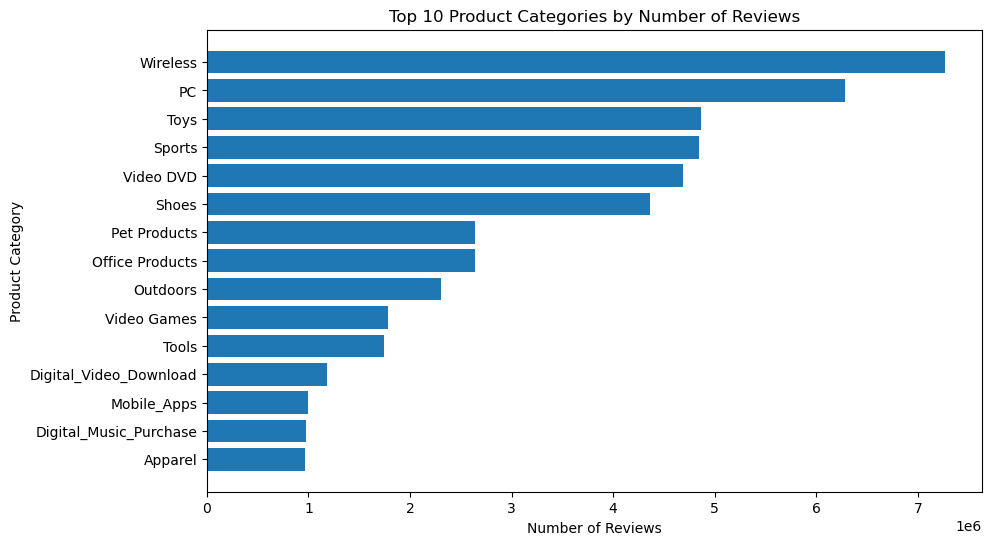

In [11]:
top_categories = df.filter(col("product_category").isNotNull()) \
    .groupBy("product_category") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(15)

pdf = top_categories.toPandas()
plt.figure(figsize=(10,6))                                                                                           
plt.barh(pdf["product_category"], pdf["count"])
plt.title("Top 10 Product Categories by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.show()


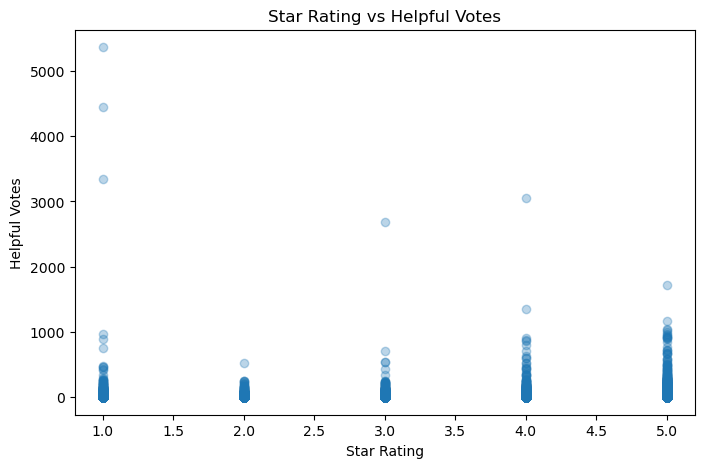

In [12]:
scatter_df = df.select("star_rating", "helpful_votes") \
    .filter(col("star_rating").isNotNull()) \
    .filter(col("helpful_votes").isNotNull()) \
    .sample(0.01)

pdf = scatter_df.toPandas()
plt.figure(figsize=(8,5))
plt.scatter(
    pdf["star_rating"].astype(float),
    pdf["helpful_votes"],
    alpha=0.3
)

plt.title("Star Rating vs Helpful Votes")
plt.xlabel("Star Rating")
plt.ylabel("Helpful Votes")
plt.show()

In [14]:
#Get the active Spark Context and URL
sc = spark.sparkContext

url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

#Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

#Format into a readable DataFrame
executor_df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
executor_df['maxMemory_GB'] = (executor_df['maxMemory'] / (1024**3)).round(2)
executor_df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,455501414,0,True,0.42


In [15]:
df.select(
    "star_rating",
    "helpful_votes",
    "total_votes",
    "verified_purchase",
    "product_category",
    "review_body"
).where(
    col("star_rating").isNull() |
    col("helpful_votes").isNull() |
    col("total_votes").isNull() |
    col("verified_purchase").isNull() |
    col("product_category").isNull() |
    col("review_body").isNull()
).count()   ## checking the count for null values

8492

In [16]:
df_dropped = df.dropna(subset=[
    "verified_purchase",
    "product_category",
    "review_body"
])
df_dropped = df_dropped.withColumn(
    "star_rating",
    col("star_rating").cast("double")
)

In [17]:
imputer = Imputer(
    inputCols=[
        "star_rating",
        "helpful_votes",
        "total_votes"
    ],
    outputCols=[
        "star_rating_imputed",
        "helpful_votes_imputed",
        "total_votes_imputed"
    ]
)
# gets the means from each of these variables and inputs them in place of null values
imputer_model = imputer.fit(df_dropped)
df_imputed = imputer_model.transform(df_dropped)

In [18]:
df_features = df_imputed.withColumn(
    "review_length",
    length(col("review_body"))
)

df_features = df_features.withColumn(
    "helpful_label",
    when(col("helpful_votes_imputed") > 0, 1).otherwise(0)
)

In [19]:
df_features.select(
    "review_body",
    "review_length",
    "helpful_votes_imputed",
    "helpful_label"#binary yes or no if a label is helpful
).show(5)

+--------------------+-------------+---------------------+-------------+
|         review_body|review_length|helpful_votes_imputed|helpful_label|
+--------------------+-------------+---------------------+-------------+
|this is the first...|          273|                    0|            0|
|I've always been ...|          272|                    0|            0|
|This is a book ab...|          410|                    1|            1|
|This is quite pos...|          211|                    0|            0|
|The story behind ...|          100|                    0|            0|
+--------------------+-------------+---------------------+-------------+
only showing top 5 rows



In [20]:
product_category_idx = StringIndexer(
    inputCol="product_category",
    outputCol="product_category_index",
    handleInvalid="keep"
)

In [21]:
df_indexed = product_category_idx.fit(df_features).transform(df_features)

In [22]:
product_category_encoder = OneHotEncoder(
    inputCol="product_category_index",
    outputCol="product_category_encoded"
)

In [23]:
encoded_model = product_category_encoder.fit(df_indexed)

df_encoded = encoded_model.transform(df_indexed)

In [24]:
df_encoded.select(
    "product_category",
    "product_category_index",
    "product_category_encoded"
).show(10, truncate=False)##check

+----------------+----------------------+------------------------+
|product_category|product_category_index|product_category_encoded|
+----------------+----------------------+------------------------+
|Books           |29.0                  |(38,[29],[1.0])         |
|Books           |29.0                  |(38,[29],[1.0])         |
|Books           |29.0                  |(38,[29],[1.0])         |
|Books           |29.0                  |(38,[29],[1.0])         |
|Books           |29.0                  |(38,[29],[1.0])         |
|Books           |29.0                  |(38,[29],[1.0])         |
|Music           |18.0                  |(38,[18],[1.0])         |
|Video           |27.0                  |(38,[27],[1.0])         |
|Books           |29.0                  |(38,[29],[1.0])         |
|Books           |29.0                  |(38,[29],[1.0])         |
+----------------+----------------------+------------------------+
only showing top 10 rows



In [25]:
assem = VectorAssembler(
    inputCols=[
        "star_rating_imputed",
        "total_votes_imputed",
        "review_length"
    ],
    outputCol="features_unscaled"
)

In [26]:
df_assembled = assem.transform(df_encoded)

In [27]:
scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features"
)

In [28]:
scaler_model = scaler.fit(df_assembled)

df_scaled = scaler_model.transform(df_assembled)

In [29]:
df_sample = df_scaled.sample(fraction=0.01, seed=42)

train_data, test_data = df_sample.randomSplit([0.8, 0.2], seed=42)

In [30]:
dt1 = DecisionTreeClassifier(
    labelCol="helpful_label",
    featuresCol="features",
    maxDepth=5
)

In [31]:
dt_model = dt1.fit(train_data)

In [32]:
print(dt_model.toDebugString)

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_135d93012a4c, depth=5, numNodes=17, numClasses=2, numFeatures=3
  If (feature 1 <= 0.02604595529955392)
   Predict: 0.0
  Else (feature 1 > 0.02604595529955392)
   If (feature 1 <= 0.07813786589866176)
    If (feature 2 <= 0.06816354207887879)
     If (feature 2 <= 0.030199037629883005)
      Predict: 0.0
     Else (feature 2 > 0.030199037629883005)
      If (feature 0 <= 2.702691652496608)
       Predict: 0.0
      Else (feature 0 > 2.702691652496608)
       Predict: 1.0
    Else (feature 2 > 0.06816354207887879)
     Predict: 1.0
   Else (feature 1 > 0.07813786589866176)
    If (feature 2 <= 0.18723403330527463)
     If (feature 2 <= 0.054358267733789406)
      If (feature 0 <= 2.702691652496608)
       Predict: 0.0
      Else (feature 0 > 2.702691652496608)
       Predict: 1.0
     Else (feature 2 > 0.054358267733789406)
      Predict: 1.0
    Else (feature 2 > 0.18723403330527463)
     Predict: 1.0



In [ ]:
# Evaluation

In [33]:
train_pred = dt_model.transform(train_data)
test_pred = dt_model.transform(test_data) 

In [34]:
#Training samples top 10 
train_pred.select(
    "helpful_label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-------------+----------+-----------------------------------------+
|helpful_label|prediction|probability                              |
+-------------+----------+-----------------------------------------+
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
|0            |0.0       |[1.0,0.0]                                |
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
|0            |1.0       |[0.060199230787606604,0.9398007692123934]|
|1            |1.0       |[0.3164188904000375,0.6835811095999624]  |
|0            |0.0       |[1.0,0.0]                                |
|0            |0.0       |[1.0,0.0]                                |
|0            |0.0       |[1.0,0.0]                                |
+-------------+----------+-----------------------------------------+
only showing top 10 rows



In [36]:
#Test samples top 10 
test_pred.select(
    "helpful_label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-------------+----------+-----------------------------------------+
|helpful_label|prediction|probability                              |
+-------------+----------+-----------------------------------------+
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
|1            |1.0       |[0.3164188904000375,0.6835811095999624]  |
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
|1            |1.0       |[0.3164188904000375,0.6835811095999624]  |
|0            |0.0       |[1.0,0.0]                                |
|0            |1.0       |[0.19651125228814473,0.8034887477118553] |
|0            |0.0       |[1.0,0.0]                                |
|0            |0.0       |[1.0,0.0]                                |
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
|1            |1.0       |[0.060199230787606604,0.9398007692123934]|
+-------------+----------+-----------------------------------------+
only showing top 10 rows



In [39]:
#Accuracy evaluation

evaluator = MulticlassClassificationEvaluator(
    labelCol="helpful_label",
    predictionCol="prediction",
    metricName="accuracy"
)

In [40]:
#Training cs Test error 
train_acc = evaluator.evaluate(train_pred)
test_acc = evaluator.evaluate(test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("Training Error:", 1 - train_acc)
print("Test Error:", 1 - test_acc)

Training Accuracy: 0.9291019072630989
Test Accuracy: 0.929577343399869
Training Error: 0.07089809273690106
Test Error: 0.07042265660013103


In [41]:
#Different model with different hyperparameters

dt3 = RandomForestClassifier(
    labelCol="helpful_label",
    featuresCol="features",
    numTrees=20
)

dt3_model = dt3.fit(train_data)

In [42]:
#Predictions
train_pred_dt3 = dt3_model.transform(train_data)
test_pred_dt3 = dt3_model.transform(test_data)

In [43]:
#Evaluation 
train_acc_dt3 = evaluator.evaluate(train_pred_dt3)
test_acc_dt3 = evaluator.evaluate(test_pred_dt3)

print("Random Forest")
print("Train:", train_acc_dt3)
print("Test:", test_acc_dt3)

Random Forest
Train: 0.929287036638395
Test: 0.9298617575068087
